In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from dreamsApp.core.pipeline import DreamsPipeline
from dreamsApp.core.config import PipelineConfig
from dreamsApp.core.database import db_manager



In [ ]:
config = PipelineConfig()
pipeline = DreamsPipeline(config=config)


In [ ]:
csv_path = "data.csv" #Replace it with the CSV path

pipeline.ingest_csv(csv_path)


In [ ]:
# These direct connections with the databases are temporary and will be abstracted by further development.
# Currently, these are only for showing how the pipeline would work.
with sqlite3.connect(db_manager.db_path) as conn:
    
    conn.row_factory = sqlite3.Row
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM posts ORDER BY timestamp ASC")
    rows = cursor.fetchall()
        
users_data = {}
for r in rows:
    uid = r["user_id"]
    post_obj = {
        "timestamp": r["timestamp"],
        "sentiment": {
            "label": r["sentiment_label"],
            "score": r["sentiment_score"]
        },
        "_id": r["id"] 
    }
    users_data.setdefault(uid, []).append(post_obj)

In [18]:
# This Plotting function is directly copied from the Flask app, with some modifications to run on notebooks.
# These functions will also be abstracted with further development

def generate_trajectory_plot(uid, posts):
    import pandas as pd
    import matplotlib.pyplot as plt

    print(f"\n4. Generating visual plot for {uid}...")
    
    df = pd.DataFrame(posts)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
    df['score'] = df['sentiment'].apply(lambda x: sentiment_map.get(x['label'], 0))
    
    df = df.sort_values("timestamp")
    df["cumulative_score"] = df["score"].cumsum()
    df["rolling_avg"] = df["score"].rolling(window=5, min_periods=1).mean()
    df["ema_score"] = df["score"].ewm(span=5, adjust=False).mean()

    plt.style.use('dark_background')
    plt.figure(figsize=(12, 6), facecolor='#121212')

    ax = plt.gca()
    ax.set_facecolor('#1e1e1e')

    plt.plot(df["timestamp"], df["cumulative_score"],
             label="Overall Emotional Journey", marker="o", alpha=0.5)

    plt.plot(df["timestamp"], df["rolling_avg"],
             label="5-Day Emotional Smoothing", linestyle="--", marker="x")

    plt.plot(df["timestamp"], df["ema_score"],
             label="Recent Emotional Trend", linestyle="-", marker="s")

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.title(f"How This Person's Feelings Shifted Over Time - {uid}")
    plt.xlabel("When Posts Were Made")
    plt.ylabel("Mood Score (Higher = Happier)")

    plt.legend()
    plt.grid(linestyle=':', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()


4. Generating visual plot for user_123...


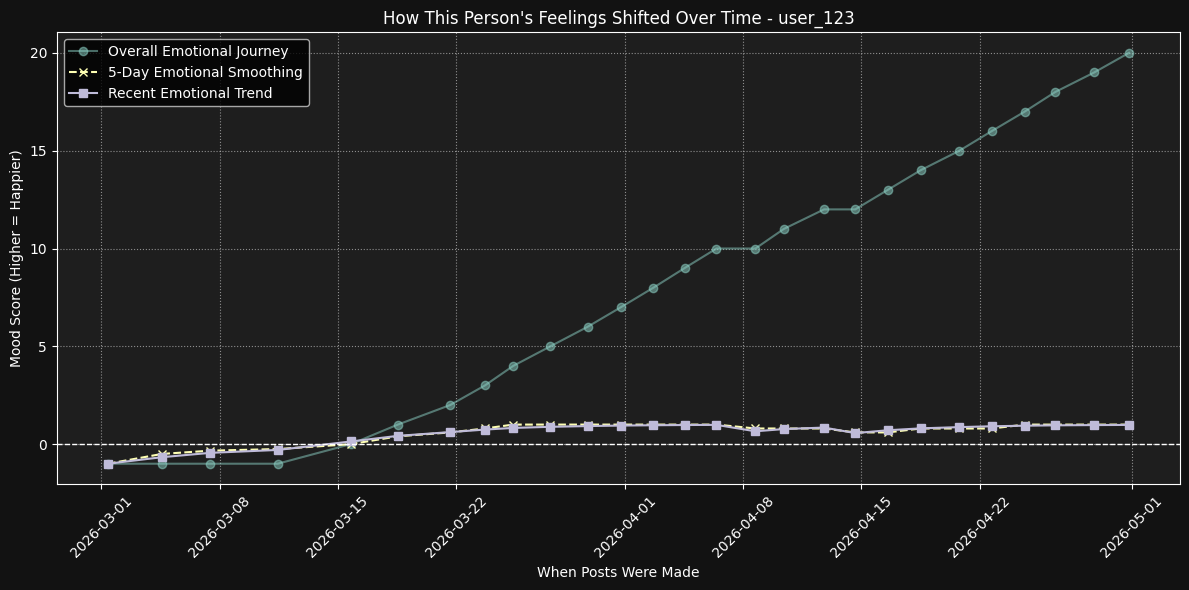

In [19]:
## The loop which uses the plotting functions.
for uid, posts in users_data.items():
    if len(posts) < 2:
        print(f"\nUser '{uid}' has fewer than 2 posts, skipping plotting.")
        continue
            
    generate_trajectory_plot(uid, posts)